Анализ метрик и RFM-сегментация клиентов

In [1]:
# Загружмаем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

In [5]:
df = pd.read_csv('D:/Projects/data-analytics-online-retail-/data/clean/OnlineRetail_clean.csv', parse_dates=['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [6]:
# Рассчитаем ключевые бизнес-метрики
total_revenue = df['TotalPrice'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()

print(f"Общая выручка: {total_revenue:,.0f}")
print(f"Количество заказов: {total_orders}")
print(f"Количество клиентов: {total_customers}")
print(f"Средний чек: {avg_order_value:.2f}")


Общая выручка: 8,911,408
Количество заказов: 18536
Количество клиентов: 4339
Средний чек: 480.76


In [7]:
# Группировка по странам (кроме UK)
country_stats = (
    df.groupby('Country')['TotalPrice']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
)

country_stats.head(10)

,sum,mean,count
Country,,,
United Kingdom,7308391.554,20.625073,354345
Netherlands,285446.340,120.798282,2363
EIRE,265545.900,36.687745,7238
Germany,228867.140,25.311562,9042
France,209024.050,25.056827,8342
Australia,138521.310,116.895620,1185
Spain,61577.110,24.779521,2485
Switzerland,56443.950,30.642752,1842
Belgium,41196.340,20.283772,2031


💬 Комментарий:

Можно увидеть, какие страны приносят наибольшую выручку после Великобритании —
например, Нидерланды, Германия, Франция и Ирландия.

In [9]:
# Подготовка данных для RFM-анализа
# RFM = Recency, Frequency, Monetary
# Recency — сколько дней прошло с последней покупки
# Frequency — сколько покупок сделал клиент
# Monetary — сколько денег клиент принёс
# Определяем "сегодня" как день после последнего заказа

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Группировка по клиентам
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


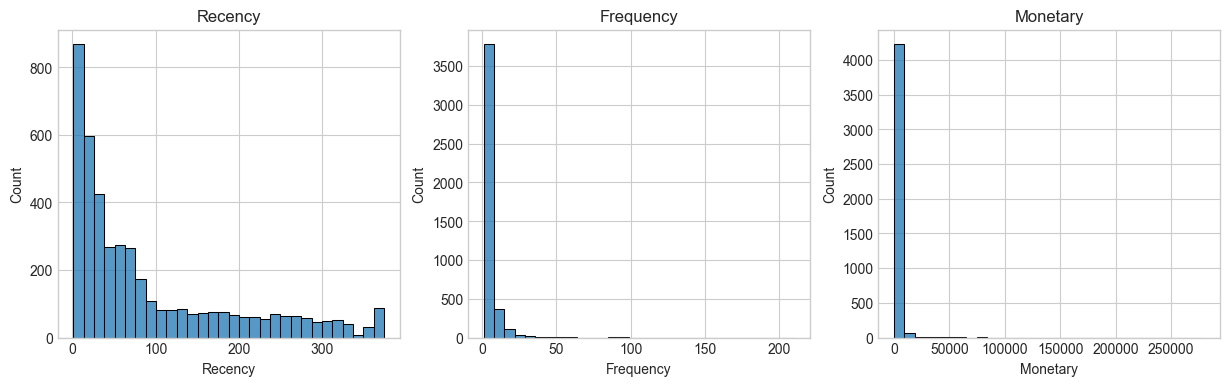

In [10]:
# Проверим распределения признаков
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title('Recency')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title('Frequency')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title('Monetary')

plt.show()


💬 Комментарий:
Распределения сильно скошены — большинство клиентов совершают мало заказов и на небольшие суммы.

In [11]:
# Присвоим квантильные оценки (1–5)
rfm['R_quartile'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_quartile'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_quartile'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = (
    rfm['R_quartile'].astype(str) +
    rfm['F_quartile'].astype(str) +
    rfm['M_quartile'].astype(str)
)
rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112


In [13]:
# Определим сегменты клиентов
def rfm_segment(row):
    if row['R_quartile'] >= '4' and row['F_quartile'] >= '4' and row['M_quartile'] >= '4':
        return 'Top Customers'
    elif row['R_quartile'] >= '3' and row['F_quartile'] >= '3':
        return 'Loyal Customers'
    elif row['R_quartile'] >= '4' and row['F_quartile'] <= '2':
        return 'Recent Customers'
    elif row['R_quartile'] <= '2' and row['F_quartile'] >= '4':
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
rfm['Segment'].value_counts()

TypeError: '>=' not supported between instances of 'int' and 'str'